# Código Final — Comparação de Modelos Supervisionados
### Predição de Doença Cardiovascular | Dataset Kaggle "Cardiovascular Disease"

Este notebook consolida a comparação entre os 3 algoritmos treinados
individualmente nas Partes 1, 2 e 3 (Regressão Logística, Random Forest,
SVM). Ele carrega os resultados já treinados a partir dos arquivos
`.pkl` salvos por cada notebook.

**Conteúdo:**
1. Carregamento e pré-processamento dos dados (necessário apenas para
   reconstruir o conjunto de teste usado na comparação)
2. Redução de dimensionalidade (PCA)
3. Função de avaliação (referência, não é chamada novamente aqui)
4. Carregamento dos resultados salvos (.pkl)
5. Comparação final entre os modelos (tabela + gráficos)
6. Conclusão

> Pré-requisito: rode as Partes 1, 2 e 3 antes deste notebook, garantindo
> que os arquivos `resultados_lr.pkl`, `resultados_rf.pkl` e
> `resultados_svm.pkl` estejam salvos em `/content/drive/MyDrive/IA/Cardiovascular Disease/Resultados/`.


## 1. Importação das bibliotecas

In [1]:
# Parte 0 — Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")


## 2. Carregamento do dataset

In [2]:
# Parte 1 — Carregamento do dataset "Cardiovascular Disease"
# Fonte: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
#
# OPÇÃO A (recomendada no Colab): baixar via kagglehub
# É necessário ter uma conta Kaggle e o arquivo kaggle.json configurado
# (kagglehub pede login/token na primeira execução).

!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
print("Dataset baixado em:", path)

csv_path = os.path.join(path, "cardio_train.csv")
df = pd.read_csv(csv_path, sep=";")
print(df.shape)
df.head()


Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.
Dataset baixado em: /kaggle/input/cardiovascular-disease-dataset
(70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
# OPÇÃO B (alternativa manual): caso prefira, faça upload manual do
# arquivo "cardio_train.csv" (baixado do Kaggle) e descomente as linhas abaixo.

# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv("cardio_train.csv", sep=";")
# df.head()


## 3. Pré-processamento

In [3]:
# Parte 3 — Pré-processamento e engenharia de atributos
df = df.drop(columns=["id"])

# Idade estava em dias -> converter para anos
df["age_years"] = (df["age"] / 365.25).round(1)
df = df.drop(columns=["age"])

# Índice de Massa Corporal (IMC), a partir de peso (kg) e altura (cm)
df["bmi"] = df["weight"] / (df["height"] / 100) ** 2

# Remoção de valores fisiologicamente impossíveis / outliers grosseiros
# (erros comuns de digitação neste dataset, ver discussões do Kaggle)
df = df[(df["ap_hi"] >= 80) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)]
df = df[df["ap_hi"] >= df["ap_lo"]]
df = df[(df["height"] >= 120) & (df["height"] <= 220)]
df = df[(df["weight"] >= 30) & (df["weight"] <= 200)]

print(f"Formato do dataset após a limpeza: {df.shape}")

X = df.drop(columns=["cardio"])
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train_scaled.shape, " | Teste:", X_test_scaled.shape)


Formato do dataset após a limpeza: (68613, 13)
Treino: (54890, 12)  | Teste: (13723, 12)


## 4. Redução de dimensionalidade (PCA)

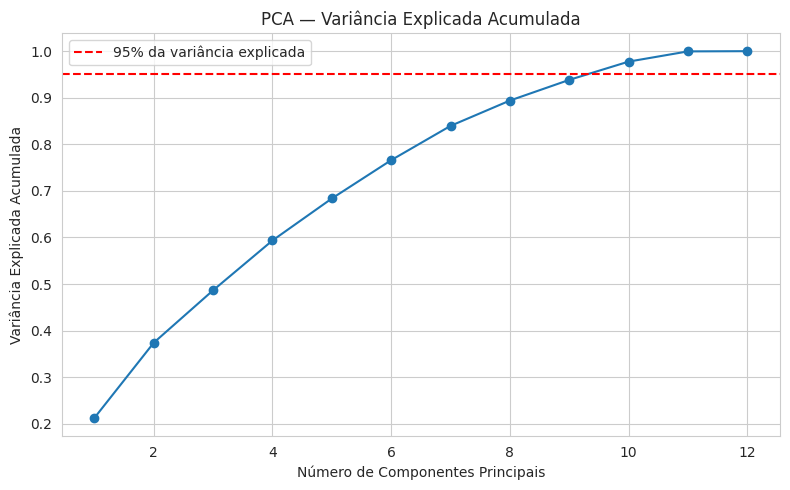

Número de componentes escolhido (>=95% da variância): 10
Formato após PCA -> treino: (54890, 10)  teste: (13723, 10)


In [4]:
# Parte 4 — Redução de dimensionalidade (PCA)
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% da variância explicada")
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Variância Explicada Acumulada")
plt.title("PCA — Variância Explicada Acumulada")
plt.legend()
plt.tight_layout()
plt.show()

n_components = int(np.argmax(variancia_acumulada >= 0.95) + 1)
print(f"Número de componentes escolhido (>=95% da variância): {n_components}")

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Formato após PCA -> treino:", X_train_pca.shape, " teste:", X_test_pca.shape)


## 5. Função de avaliação

In [5]:
# Parte 5 — Função auxiliar de avaliação (métricas adequadas ao problema)
# Problema de classificação binária em saúde -> além da acurácia,
# olhamos recall/precisão/F1 e ROC-AUC (importante p/ dados quase balanceados
# e onde falsos negativos, i.e. deixar de detectar doença, são custosos).

def avaliar_modelo(nome, modelo, X_test, y_test, plotar=True):
    y_pred = modelo.predict(X_test)
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = modelo.decision_function(X_test)

    metricas = {
        "Modelo": nome,
        "Acuracia": accuracy_score(y_test, y_pred),
        "Precisao": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
    }

    print(f"\n=== {nome} ===")
    print(classification_report(y_test, y_pred, target_names=["Sem doença", "Com doença"]))

    if plotar:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
        axes[0].set_title(f"Matriz de Confusão — {nome}")
        axes[0].set_xlabel("Predito")
        axes[0].set_ylabel("Real")

        RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
        axes[1].set_title(f"Curva ROC — {nome}")
        plt.tight_layout()
        plt.show()

    return metricas

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 6. Carregamento dos resultados salvos (.pkl)

Os 3 modelos já foram treinados (com Grid Search + Validação Cruzada)
individualmente nas Partes 1, 2 e 3.
Aqui apenas são carregados os dicionários de métricas (`resultados_*.pkl`) que
cada notebook exportou via `avaliar_modelo(...)`.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pickle

PASTA_RESULTADOS = "/content/drive/MyDrive/IA/Cardiovascular Disease/Resultados/"

caminhos_pkl = {
    "Regressão Logística": os.path.join(PASTA_RESULTADOS, "resultados_lr.pkl"),
    "Random Forest": os.path.join(PASTA_RESULTADOS, "resultados_rf.pkl"),
    "SVM": os.path.join(PASTA_RESULTADOS, "resultados_svm.pkl"),
}

# Verificação prévia: garante que os 3 arquivos existem antes de tentar carregar
faltando = [nome for nome, caminho in caminhos_pkl.items() if not os.path.exists(caminho)]
if faltando:
    raise FileNotFoundError(
        "Os seguintes arquivos .pkl não foram encontrados: "
        f"{faltando}. Rode as Partes 1-3 antes deste notebook, ou "
        "confira o caminho em PASTA_RESULTADOS."
    )

resultados_por_modelo = {}
for nome, caminho in caminhos_pkl.items():
    with open(caminho, "rb") as f:
        resultados_por_modelo[nome] = pickle.load(f)
    tamanho_kb = os.path.getsize(caminho) / 1024
    print(f"✅ {nome}: carregado de {caminho} ({tamanho_kb:.1f} KB)")

resultados_lr = resultados_por_modelo["Regressão Logística"]
resultados_rf = resultados_por_modelo["Random Forest"]
resultados_svm = resultados_por_modelo["SVM"]

print("\nResultados carregados (sem re-treinamento):")
for nome, r in resultados_por_modelo.items():
    print(f"  {nome}: ROC_AUC={r['ROC_AUC']:.4f} | F1={r['F1']:.4f}")

✅ Regressão Logística: carregado de /content/drive/MyDrive/IA/Cardiovascular Disease/Resultados/resultados_lr.pkl (0.2 KB)
✅ Random Forest: carregado de /content/drive/MyDrive/IA/Cardiovascular Disease/Resultados/resultados_rf.pkl (0.2 KB)
✅ SVM: carregado de /content/drive/MyDrive/IA/Cardiovascular Disease/Resultados/resultados_svm.pkl (0.2 KB)

Resultados carregados (sem re-treinamento):
  Regressão Logística: ROC_AUC=0.7918 | F1=0.7091
  Random Forest: ROC_AUC=0.8001 | F1=0.7183
  SVM: ROC_AUC=0.7916 | F1=0.7004


## 7. Comparação final entre os modelos

Tabela e gráficos comparando os 3 algoritmos supervisionados nas métricas
relevantes para o problema (acurácia, precisão, recall, F1 e ROC-AUC).


In [8]:
tabela_comparativa = pd.DataFrame([resultados_lr, resultados_rf, resultados_svm])
tabela_comparativa = tabela_comparativa.set_index("Modelo").round(4)
tabela_comparativa = tabela_comparativa.sort_values("ROC_AUC", ascending=False)
tabela_comparativa


,Acuracia,Precisao,Recall,F1,ROC_AUC
Modelo,,,,,
Random Forest,0.7326,0.7502,0.6891,0.7183,0.8001
Regressão Logística,0.7281,0.7532,0.6699,0.7091,0.7918
SVM,0.7296,0.7750,0.6388,0.7004,0.7916


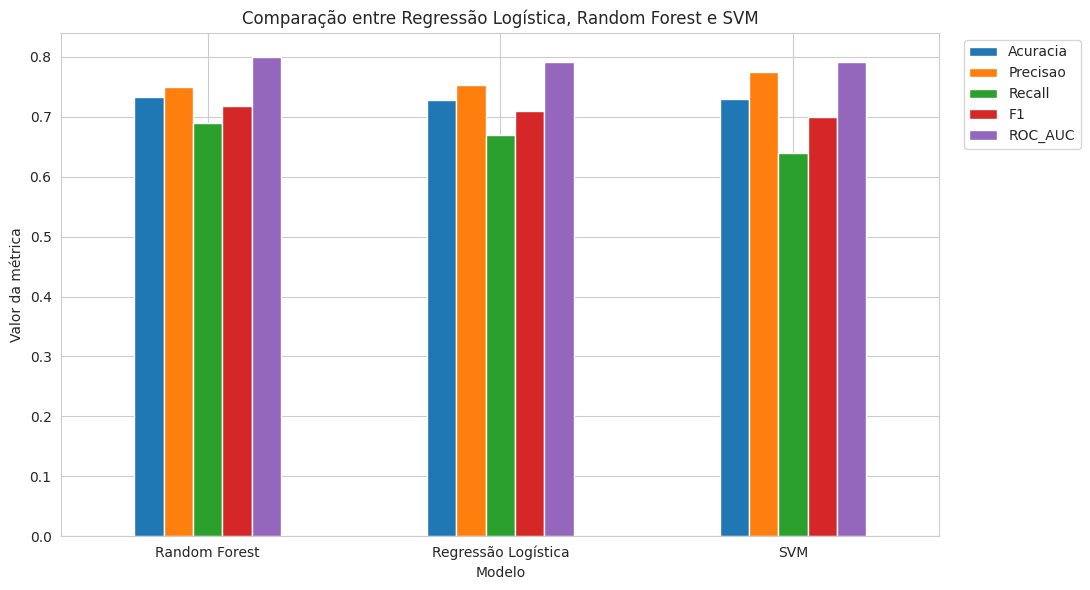

In [9]:
tabela_comparativa.plot(kind="bar", figsize=(11,6))
plt.title("Comparação entre Regressão Logística, Random Forest e SVM")
plt.ylabel("Valor da métrica")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


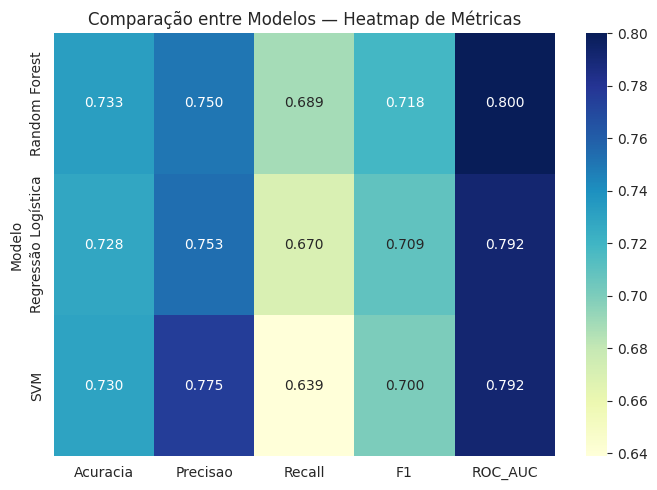

In [10]:
plt.figure(figsize=(7,5))
sns.heatmap(tabela_comparativa, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Comparação entre Modelos — Heatmap de Métricas")
plt.tight_layout()
plt.show()
